# Benchmark: Uploading dataset to s3 bucket VS Hub 
Author: Margaux Masson-Forsythe

## Imports

In [ ]:
!pip install hub==2.0.7

In [ ]:
import hub
print(hub.__version__)

2.0.7


In [ ]:
from glob import glob
import boto3
from botocore.exceptions import NoCredentialsError
from timeit import default_timer as timer
from tqdm import tqdm
import numpy as np
from PIL import Image
import os

## Load Dataset from Kaggle: A Large-Scale Dataset for Fish Segmentation and Classification: https://www.kaggle.com/crowww/a-large-scale-fish-dataset

In [ ]:
!export KAGGLE_USERNAME="xxxxx" && export KAGGLE_KEY="xxxxxxxxx" && kaggle datasets download -d crowww/a-large-scale-fish-dataset

In [ ]:
!unzip -n a-large-scale-fish-dataset.zip

In [ ]:
!ls Fish_Dataset/Fish_Dataset/

'Black Sea Sprat'   README.txt	     Segmentation_example_script.m
'Gilt-Head Bream'  'Red Mullet'      Shrimp
'Hourse Mackerel'  'Red Sea Bream'  'Striped Red Mullet'
 license.txt	   'Sea Bass'	     Trout


In [ ]:
dataset_path = './Fish_Dataset/Fish_Dataset/'

In [ ]:
files_in_fish_set = glob("./Fish_Dataset/Fish_Dataset/**/**/*.png")
print(f"There are {len(files_in_fish_set)} images in the dataset")

There are 18000 images in the dataset


In [ ]:
import fnmatch

files_in_fish_set_images = []
files_in_fish_set_GT = []
for dirpath, dirs, files in os.walk(dataset_path): 
  for filename in fnmatch.filter(files, '*.png'):
    fname = os.path.join(dirpath,filename)
    if 'GT' in fname:
      files_in_fish_set_GT.append(fname)
    else:
      files_in_fish_set_images.append(fname)

print(f'There are {len(files_in_fish_set_images)} pictures of fish and {len(files_in_fish_set_GT)} corresponding masks (GT)')

There are 9000 pictures of fish and 9000 corresponding masks (GT)


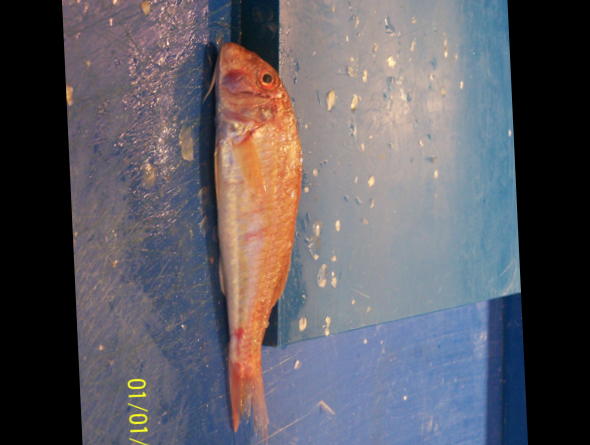

In [ ]:
# Image of the fish
Image.open(files_in_fish_set_images[0]).show()

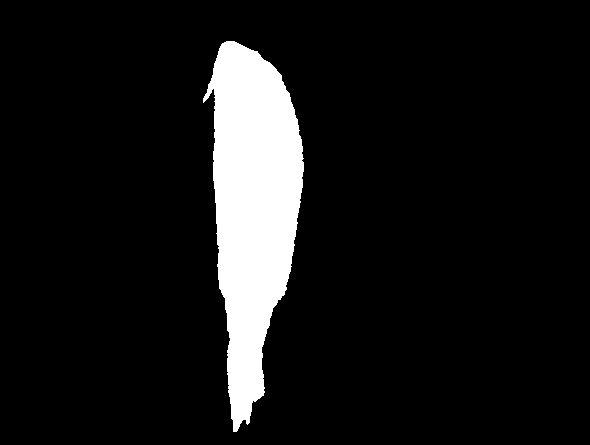

In [ ]:
# Segmentation Mask
Image.open(files_in_fish_set_GT[0]).show()

## Send dataset to s3 bucket

1) Uploading to s3 using AWS CLI

In [ ]:
# Install AWS CLI 
!pip install --upgrade awscli

In [ ]:
# Check awscli was correctly installed
!aws --version

In [ ]:
!cp /content/credentials ~/.aws/credentials

In [ ]:
# Congigure AWS credentials 
# !aws configure 

In [ ]:
# Setting up timer to perform benchmarking
start = timer()

In [ ]:
# Send dataset to s3 using aws CLI
# We created a bucket "fish-classification-segmentation-dataset" in s3 ahead of time
!aws s3 cp --recursive --no-progress --only-show-errors "./Fish_Dataset" "s3://fish-classification-segmentation-dataset" 

In [ ]:
# End timer
end = timer()
total_time_s3 = end-start

print(f"Uploading all the files in the Fish dataset to s3 took {total_time_s3} seconds")

Uploading all the files in the Fish dataset to s3 took 369.0134469759996 seconds


2) Uploading to s3 using boto3: all images / unzipped dataset

In [ ]:
def upload_to_aws(s3_client, local_file, bucket, s3_file):
    # Try to upload file to s3 bucket and handle errors that can happens. 
    # Returns True if success, False otherwise
    try:
        s3_client.upload_file(local_file, bucket, s3_file)
        print("Upload Successful")
        return True
    except FileNotFoundError:
        print("The file was not found")
        return False
    except NoCredentialsError:
        print("Credentials not available")
        return False

In [ ]:
ACCESS_KEY = 'xxxxxx'
SECRET_KEY = 'xxxxxx'
AWS_SESSION_TOKEN="xxxxxxx"


In [ ]:
# Set up connection to s3 account with credentials provided by user
s3_client = boto3.client('s3', aws_access_key_id=ACCESS_KEY,
                          aws_secret_access_key=SECRET_KEY, 
                         aws_session_token=AWS_SESSION_TOKEN)

In [ ]:
# We created a bucket in s3 called fish-classification-segmentation-dataset-boto3
bucket_name = "fish-classification-segmentation-dataset-boto3"

# Setting up timer to perform benchmarking
start = timer()

for img_path in tqdm(files_in_fish_set):
  # We only want the file's name after "./Fish_Dataset/Fish_Dataset/"
  file_name_in_s3 = img_path.split(dataset_path)[1]
  # Upload file to the bucket 
  uploaded = upload_to_aws(s3_client, img_path, bucket_name, file_name_in_s3)

# End timer
end = timer()
total_time_s3 = end-start

print(f"Uploading all the files in the Fish dataset to s3 took {total_time_s3} seconds")

3) Uploading to s3 using boto3: zipped dataset

In [ ]:
# Upload the zipped dataset
# Setting up timer to perform benchmarking
start = timer()

path_to_zipped_dataset = 'a-large-scale-fish-dataset.zip'
uploaded = upload_to_aws(s3_client, path_to_zipped_dataset, bucket_name, path_to_zipped_dataset)

# End timer
end = timer()
total_time_s3 = end-start

print(f"Uploading the zipped Fish dataset to s3 took {total_time_s3} seconds")

Upload Successful
Uploading the zipped Fish dataset to s3 took 40.643983771999956 seconds


## Send dataset to Hub Storage

In [ ]:
!activeloop login -u username -p password

In [ ]:
hub_fish_path = "hub://margauxmforsythe/fish-dataset"

In [ ]:
dataset_path

'./Fish_Dataset/Fish_Dataset/'

In [ ]:
# Find the class_names 
# we do not want the txt files to be included so we only look for the subfolders' names
class_names = [name for name in os.listdir(dataset_path) if os.path.isdir(dataset_path + name)]
print(f"There are {len(class_names)} classes: {class_names}")

There are 9 classes: ['Striped Red Mullet', 'Black Sea Sprat', 'Trout', 'Hourse Mackerel', 'Shrimp', 'Sea Bass', 'Red Mullet', 'Gilt-Head Bream', 'Red Sea Bream']


In [ ]:
# Setting up timer to perform benchmarking
start = timer()

# Uploading to Hub storage at the path: hub_asl_path
with hub.empty(hub_fish_path, overwrite=True) as ds:
    # Create the tensors with names of your choice.
    ds.create_tensor('images', htype = 'image', sample_compression = 'png')
    ds.create_tensor('masks', htype = 'image', sample_compression = 'png')
    ds.create_tensor('labels', htype = 'class_label', class_names = class_names)

    # Add arbitrary metadata - Optional
    ds.info.update(description = 'Fish classification & Segmentation dataset')
    ds.images.info.update(camera_type = 'SLR')
    
    # Iterate through the files and append to hub dataset
    for i in tqdm(range(len(files_in_fish_set_images))):
        file_image = files_in_fish_set_images[i]
        file_mask = files_in_fish_set_GT[i]
        label_text = os.path.basename(os.path.dirname(file_image))
        label_num = class_names.index(label_text)
        
        # Append to images tensor using hub.read
        ds.images.append(hub.read(file_image))  
        # Append to masks tensor using hub.read
        ds.masks.append(hub.read(file_mask))  
        # Append to labels tensor
        ds.labels.append(np.uint32(label_num)) 
                
# End timer
end = timer()
total_time_hub = end-start

print(f"Uploading all the files in the Fish dataset to Hub took {total_time_hub} seconds")

100%|██████████| 9000/9000 [16:11<00:00,  9.27it/s]


Uploading all the files in the Fish dataset to Hub took 1047.8884124840006 seconds


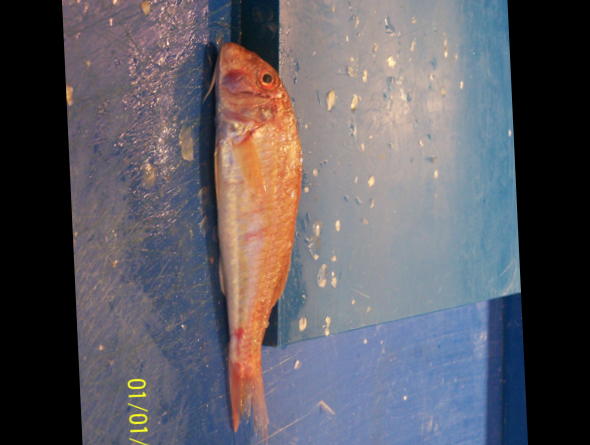

In [ ]:
Image.fromarray(ds.images[0].numpy())

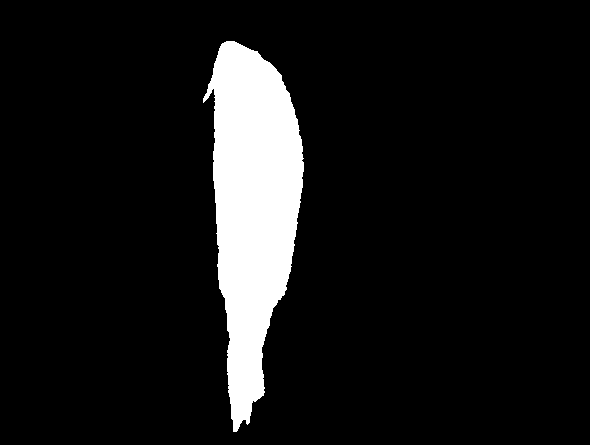

In [ ]:
Image.fromarray(ds.masks[0].numpy()*255) # grayscale mask

# could also use plt.imshow(ds.masks[0].numpy(), cmap='gray')

Check the dataset was correctly uploaded to Hub

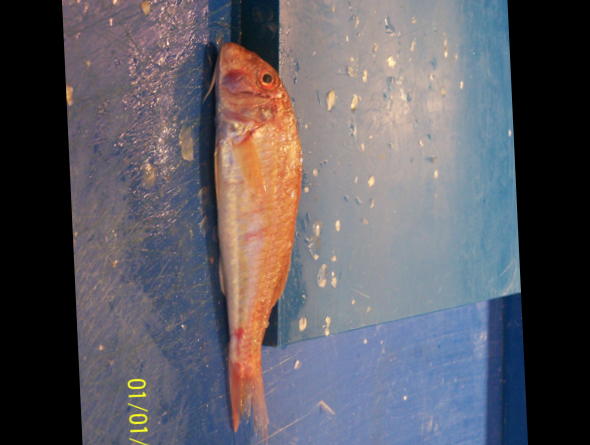

In [ ]:
ds_from_hub = hub.dataset(hub_fish_path)
Image.fromarray(ds_from_hub.images[0].numpy())

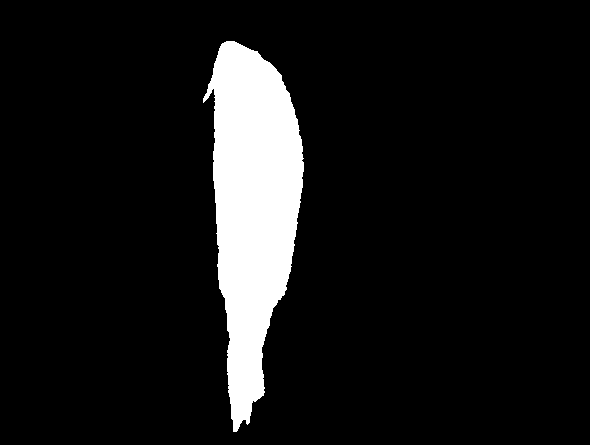

In [ ]:
Image.fromarray(ds_from_hub.masks[0].numpy()*255) # grayscale mask

In [ ]:
# Which letter or number is that?
print(class_names[ds_from_hub.labels[0].numpy()[0]])

Striped Red Mullet



Black Sea Sprat


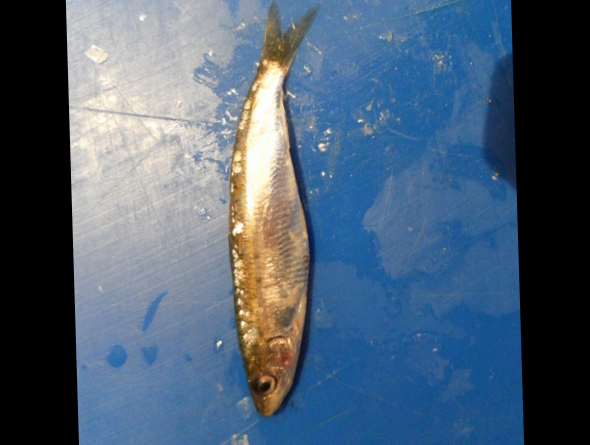

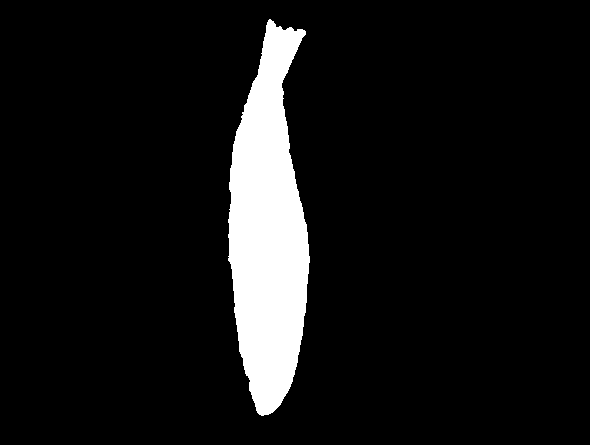


Hourse Mackerel


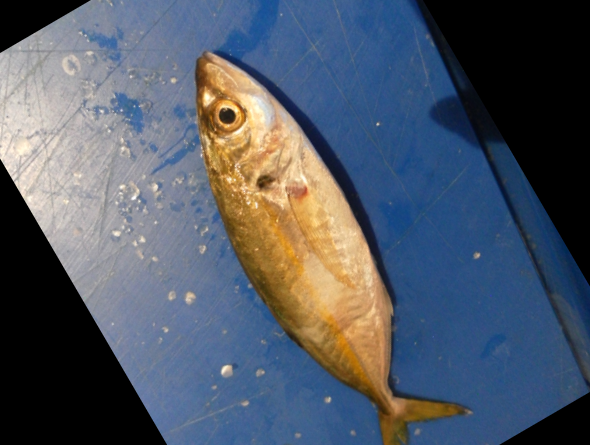

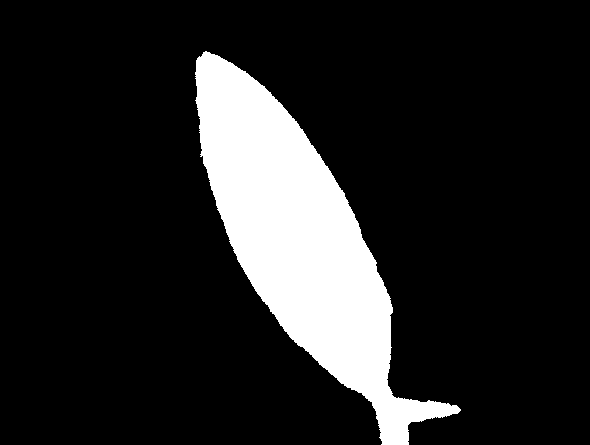


Shrimp


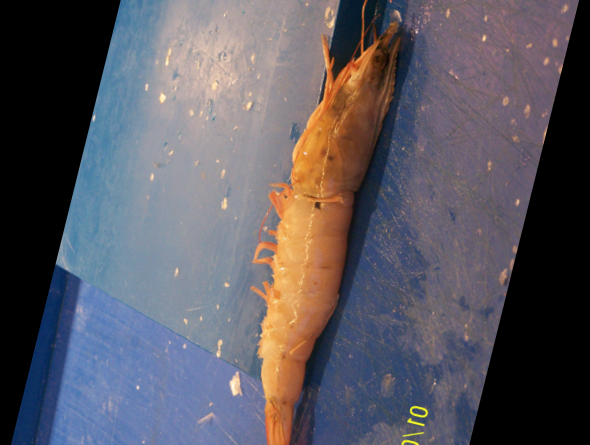

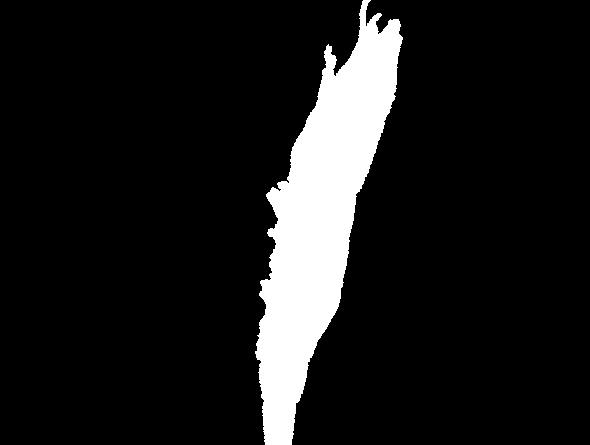


Shrimp


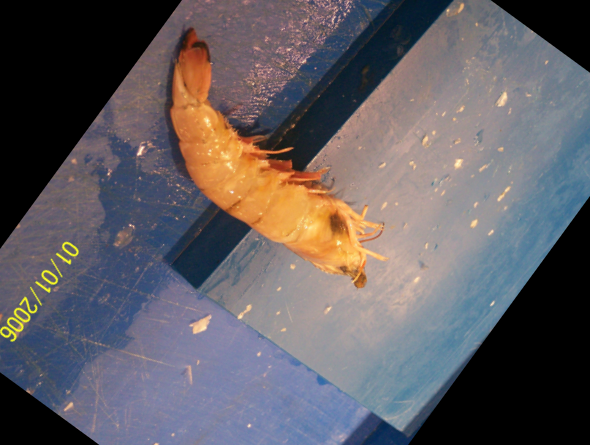

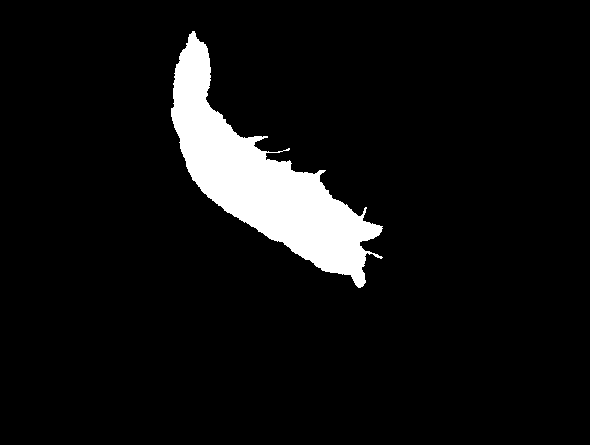


Black Sea Sprat


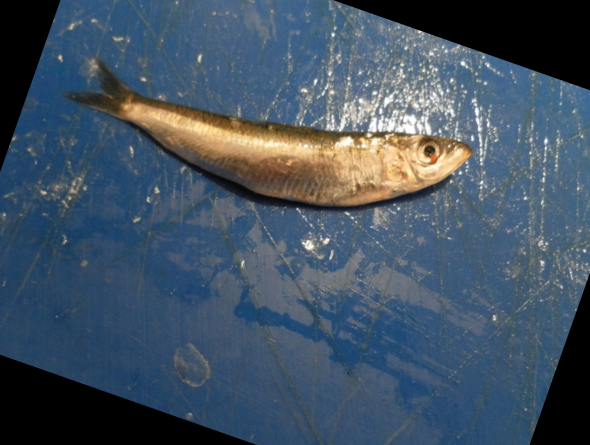

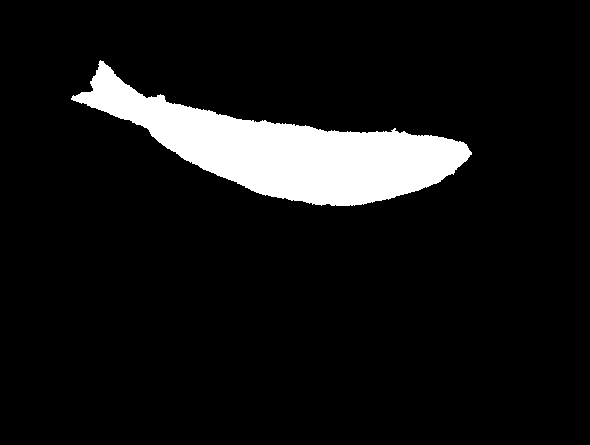


Red Sea Bream


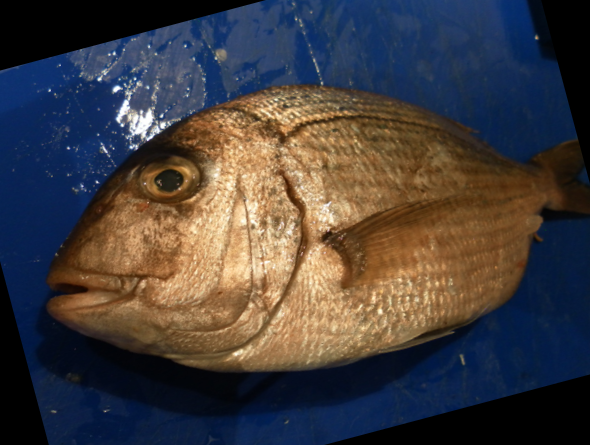

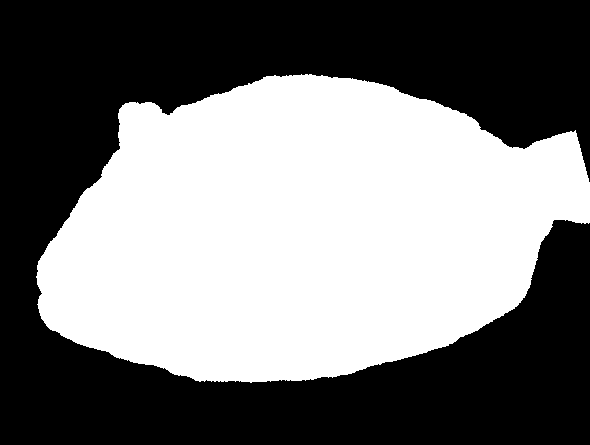


Striped Red Mullet


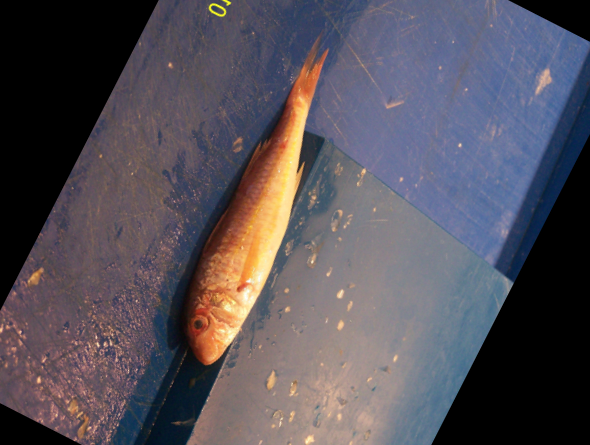

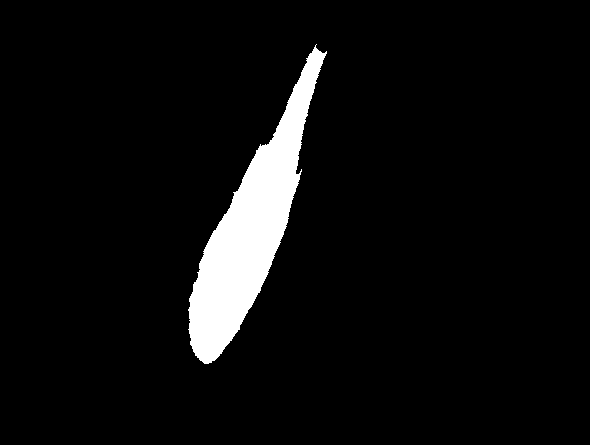


Black Sea Sprat


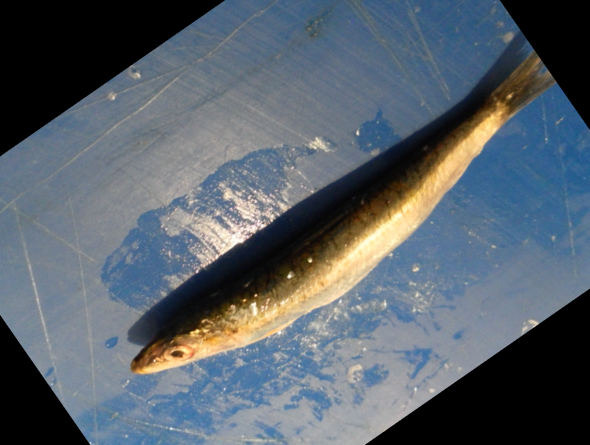

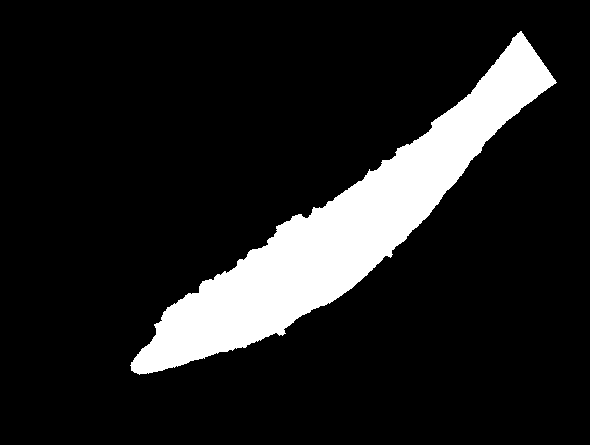

In [ ]:
import random

list_random = [random.randint(0,len(ds_from_hub)) for i in range(8)]
for i in list_random:
  print(f'\n{class_names[ds_from_hub.labels[i].numpy()[0]]}')
  Image.fromarray(ds_from_hub.images[i].numpy()).show()
  Image.fromarray(ds_from_hub.masks[i].numpy()*255).show()

With Hub Multiprocessing: https://docs.activeloop.ai/getting-started/parallel-computing

In [ ]:
@hub.compute
def file_to_hub(path_to_pair_img_mask, sample_out, class_names):
    file_image = path_to_pair_img_mask[0]
    file_mask = path_to_pair_img_mask[1]

    label_text = os.path.basename(os.path.dirname(file_image))
    label_num = class_names.index(label_text)

    # Append the label and image to the output sample
    sample_out.labels.append(np.uint32(label_num))
    sample_out.images.append(hub.read(file_image))
    sample_out.masks.append(hub.read(file_mask))
    
    return sample_out

In [ ]:
# Creating a list that combined the paths to the pairs image/mask 
list_pairs_img_mask = [[files_in_fish_set_images[i], files_in_fish_set_GT[i]] for i in range(len(files_in_fish_set_images))]

list_pairs_img_mask[0]

['./Fish_Dataset/Fish_Dataset/Striped Red Mullet/Striped Red Mullet/00361.png',
 './Fish_Dataset/Fish_Dataset/Striped Red Mullet/Striped Red Mullet GT/00361.png']

In [ ]:
hub_fish_path_parallel_computing = 'hub://margauxmforsythe/fish_dataset_parallel_computing'

# Setting up timer to perform benchmarking
start = timer()

with hub.empty(hub_fish_path_parallel_computing, overwrite=True) as ds:
    ds.create_tensor('images', htype = 'image', sample_compression = 'png')
    ds.create_tensor('masks', htype = 'image', sample_compression = 'png')
    ds.create_tensor('labels', htype = 'class_label', class_names = class_names)
    
    file_to_hub(class_names=class_names).eval(list_pairs_img_mask, ds, num_workers = 10)

# End timer
end = timer()
total_time_hub = end-start

print(f"Uploading all the files in the Fish dataset to Hub with parallel computing took {total_time_hub} seconds")

Uploading all the files in the Fish dataset to Hub with parallel computing took 182.68960309999966 seconds



Black Sea Sprat


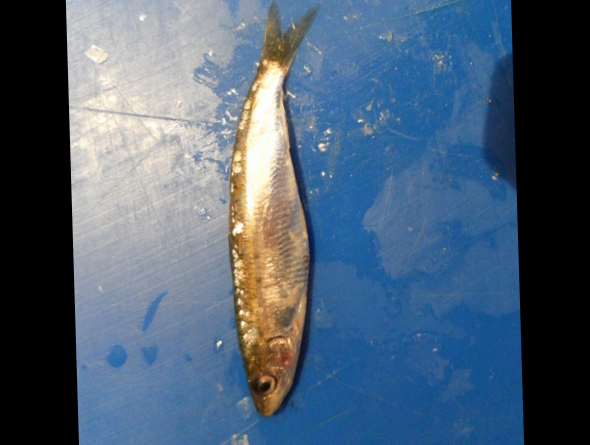

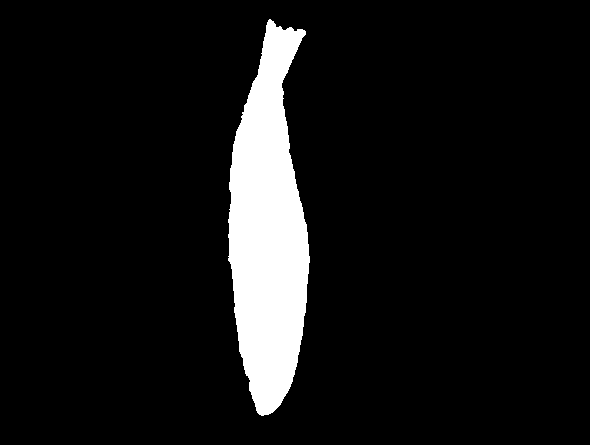


Hourse Mackerel


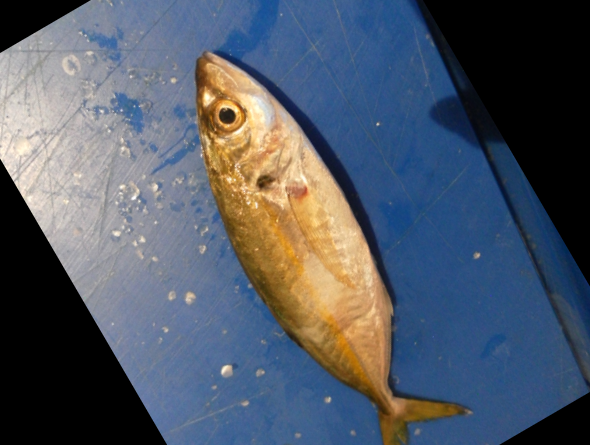

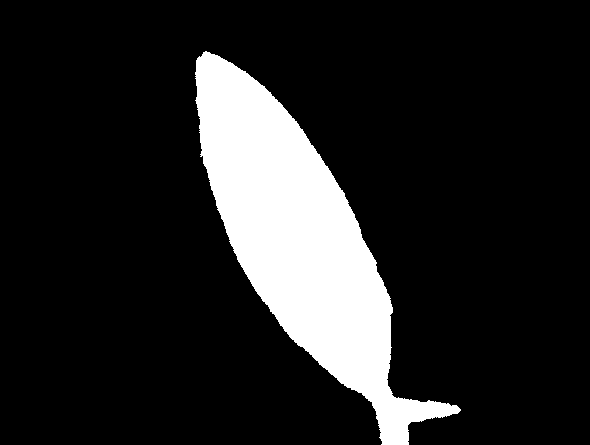


Shrimp


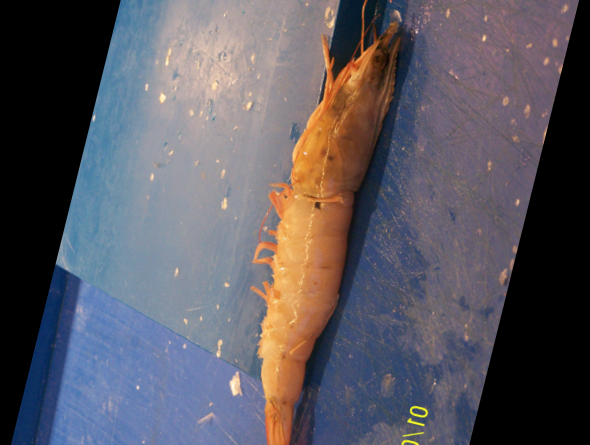

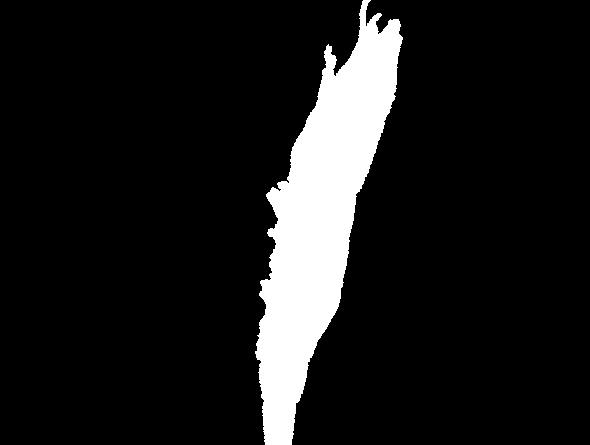


Shrimp


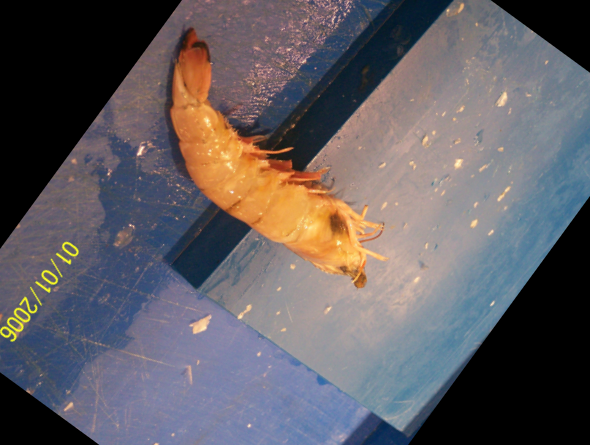

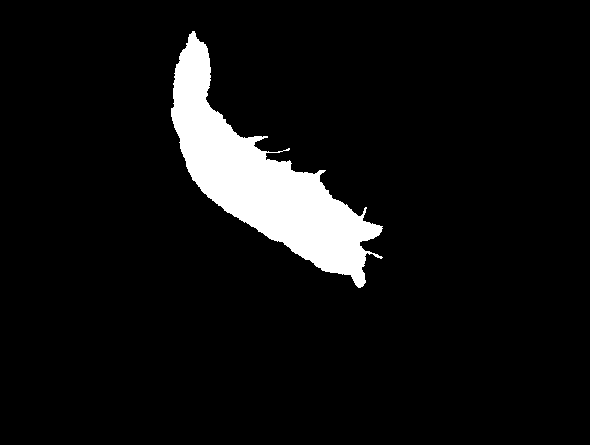


Black Sea Sprat


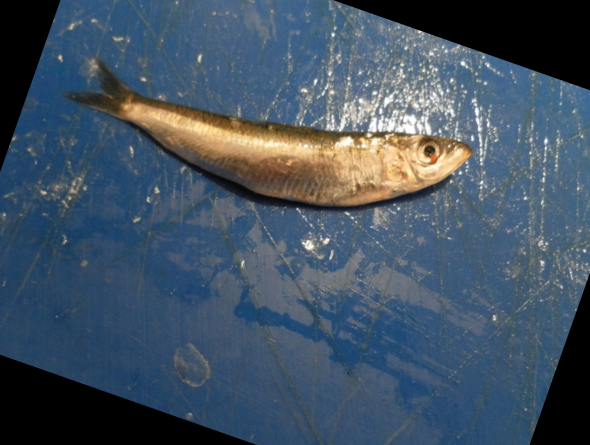

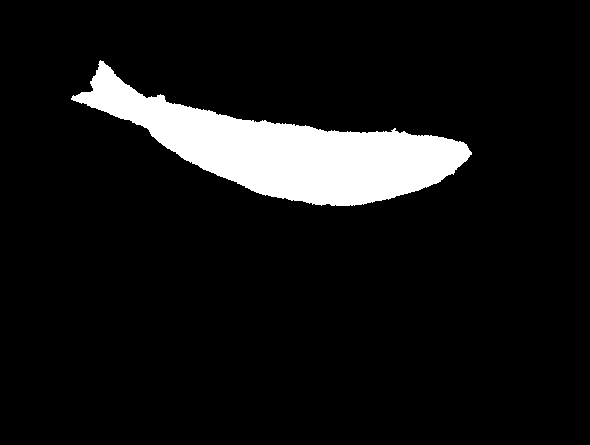


Red Sea Bream


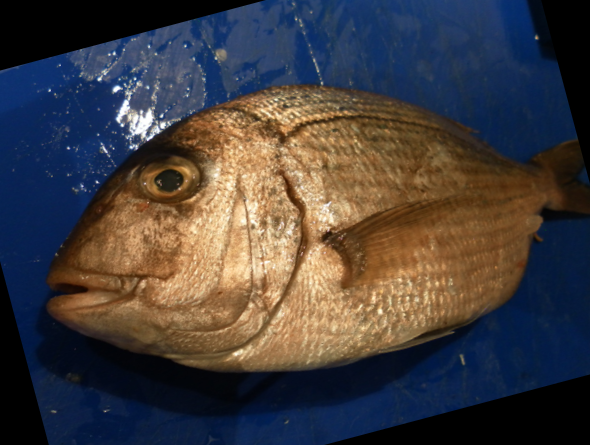

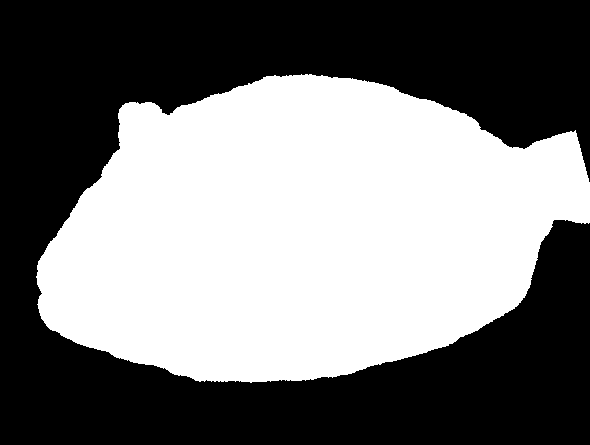


Striped Red Mullet


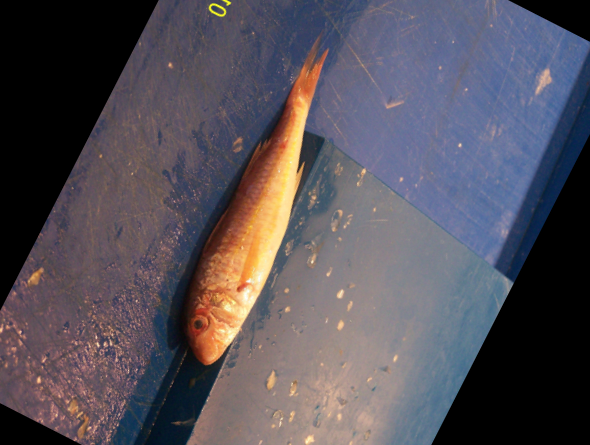

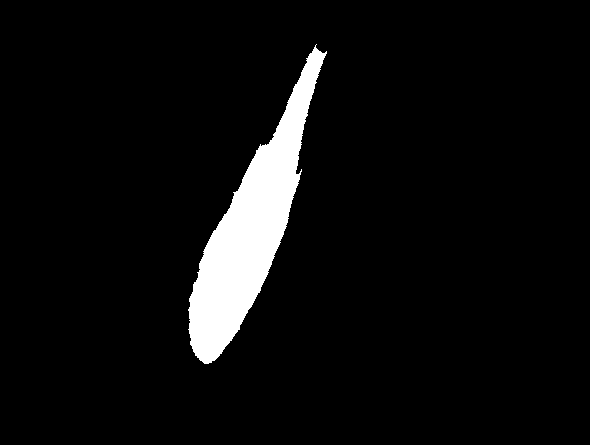


Black Sea Sprat


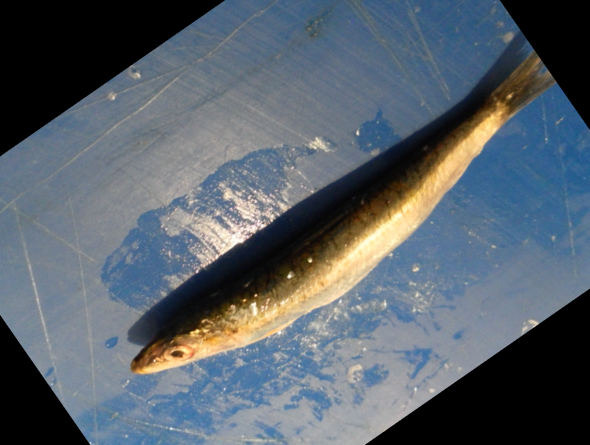

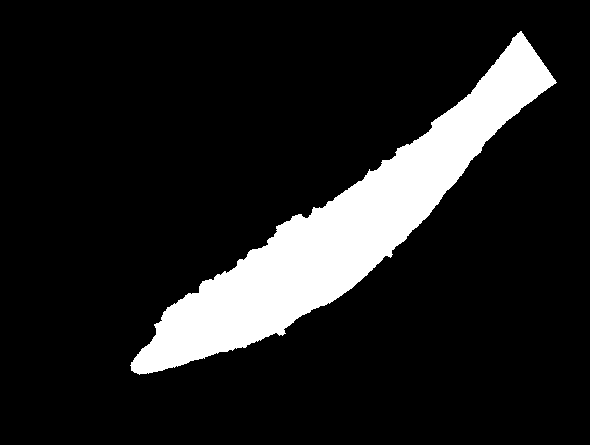

In [ ]:
ds_from_hub_parallel_computing = hub.dataset(hub_fish_path_parallel_computing)

for i in list_random:
  print(f'\n{class_names[ds_from_hub_parallel_computing.labels[i].numpy()[0]]}')
  Image.fromarray(ds_from_hub_parallel_computing.images[i].numpy()).show()
   # grayscale mask
  Image.fromarray(ds_from_hub_parallel_computing.masks[i].numpy()*255).show()